In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors

In [2]:
file_path = "../logs/10by10_100000.log"

In [3]:
with open(file_path, "r") as f:
    lines = f.read().strip().splitlines()

meta_rows = int(lines[0].split()[0])
meta_cols = int(lines[0].split()[1])
meta_n = int(lines[1])

print("Grid size:", meta_rows, "x", meta_cols)
print("Simulations:", meta_n)

def parse_line(line):
    """Parse one simulation log line into structured fields."""
    parts = []
    i = 0

    # extract the 2 [[grid]] segments
    while len(parts) < 2:
        start = line.find("[[", i)
        end = line.find("]]", start) + 2
        parts.append(line[start:end])
        i = end + 1

    # remaining fields (comma-separated)
    rest = line[i:].strip().strip(", ")
    nums = [x.strip() for x in rest.split(",")]

    # order: init_grid, final_grid, r, g, b, steps, label
    return {
        "initial_grid": parts[0],
        "final_grid": parts[1],
        "num_r": int(nums[0]),
        "num_g": int(nums[1]),
        "num_b": int(nums[2]),
        "steps": int(nums[3]),
        "label": int(nums[4])
    }

# Parse all simulation lines
records = [parse_line(line) for line in lines[2:]]

# Convert to pandas DataFrame
df = pd.DataFrame(records)

df.head()


Grid size: 10 x 10
Simulations: 100000


,initial_grid,final_grid,num_r,num_g,num_b,steps,label
0,[[..gg..g.gg][..gg...gg.][..gg..ggg.][gg..gggg...,[[r.r.r.r.r.][.r.r.r.r.r][r.r.r.r.r.][.r.r.r.r...,50,0,0,65,1
1,[[.g.gg..gg.][..g.ggg...][gg.g..g.gg][g....g.g...,[[r.r.r.r.r.][.r.r.r.r.r][r.r.r.r.r.][.r.r.r.r...,50,0,0,82,1
2,[[gg.g..gg.g][g...g..g.g][..gggg...g][..gg.gg....,[[r.r.r.r.r.][.r.r.r.r.r][r.r.r.r.r.][.r.r.r.r...,50,0,0,49,1
3,[[gg....gggg][.g.gg.gggg][.g..gg...g][...ggg.....,[[r.r.r.r.r.][.r.r.r.r.r][r.r.r.r.r.][.r.r.r.r...,50,0,0,47,1
4,[[gg.g..gggg][..g..g...g][.g....ggg.][.ggggg.g...,[[r.r.r.rbb.][.r.r.r.g..][r.r.r.r...][.r.rbbbg...,23,21,6,22,0


In [4]:
print(f"{df.label.sum()} successful simulations out of {df.index.size}")

69526 successful simulations out of 100000


In [5]:
print("avg steps for successful vs unsuccessful runs")
print(df.loc[df.label==1].steps.mean(), df.loc[df.label==0].steps.mean())

avg steps for successful vs unsuccessful runs
57.767971694042515 28.86102907396469


In [6]:
def parse_grid_string_to_2d(grid_str, meta_rows, meta_cols):
    """
    Convert a log grid string of the form:
        [[r.rbg.][.r.g..][r.r...][.r.gg.][r.rgg.]]
    into a 2D list of chars with dimensions (meta_rows x meta_cols).
    """
    # Sanity check format
    if not (grid_str.startswith("[[") and grid_str.endswith("]]")):
        raise ValueError(f"Invalid grid string format: {grid_str}")
    
    # 2. Remove the outer "[[" and "]]"
    inner = grid_str[2:-2]

    # 3. Split into row substrings
    rows = inner.split("][")   # because rows are like [...][...]

    if len(rows) != meta_rows:
        raise ValueError(
            f"Row count mismatch: expected {meta_rows}, got {len(rows)}"
        )

    # 4. Convert each row string into a list of chars
    grid = []
    for row in rows:
        if len(row) != meta_cols:
            raise ValueError(
                f"Column count mismatch in row '{row}': "
                f"expected {meta_cols}, got {len(row)}"
            )
        grid.append(list(row))

    return grid


In [7]:
def get_view(grid, r, c):
    """
    Returns a 13-length list representing the 2-hop diamond view
    around (r, c), following the exact C++ ViewIndex order:

        index: meaning     relative position
        -----------------------------------
         0      U2         (-2,  0)
         1      UL         (-1, -1)
         2      U1         (-1,  0)
         3      UR         (-1, +1)
         4      L2         ( 0, -2)
         5      L1         ( 0, -1)
         6      C          ( 0,  0)
         7      R1         ( 0, +1)
         8      R2         ( 0, +2)
         9      DL         (+1, -1)
        10      D1         (+1,  0)
        11      DR         (+1, +1)
        12      D2         (+2,  0)

    Out-of-bounds → 'x'
    """
    
    rows = len(grid)
    cols = len(grid[0])

    # Offsets in the EXACT ViewIndex order
    offsets = [
        (-2,  0),  # U2 = 0
        (-1, -1),  # UL = 1
        (-1,  0),  # U1 = 2
        (-1, +1),  # UR = 3
        ( 0, -2),  # L2 = 4
        ( 0, -1),  # L1 = 5
        ( 0,  0),  # C  = 6
        ( 0, +1),  # R1 = 7
        ( 0, +2),  # R2 = 8
        (+1, -1),  # DL = 9
        (+1,  0),  # D1 = 10
        (+1, +1),  # DR = 11
        (+2,  0),  # D2 = 12
    ]

    view = []

    for dr, dc in offsets:
        rr = r + dr
        cc = c + dc

        if 0 <= rr < rows and 0 <= cc < cols:
            view.append(grid[rr][cc])
        else:
            view.append('x')  # outside → boundary mark

    return view


In [8]:
# --- helpers: color map for characters ---
CHAR_PALETTE = {
    'r': '#d62728',   # red
    'g': '#2ca02c',   # green
    'b': '#1f77b4',   # blue
    '.': '#ffffff',   # white (empty)
    'x': '#aaaaaa',   # gray (boundary / outside)
    '?': '#f0f0f0',   # fallback
}

def char_to_color(ch):
    return CHAR_PALETTE.get(ch, CHAR_PALETTE['?'])

# --- main visualization function ---
def visualize_grid_and_view(grid, view13, position=None, figsize=(10,5), title=None):
    """
    Visualize the whole grid and a 13-cell diamond view.

    Args:
      grid: 2D list of chars (rows x cols) with chars in {'r','g','b','.','x'}
      view13: list of length 13 in ViewIndex order:
             [U2, UL, U1, UR, L2, L1, C, R1, R2, DL, D1, DR, D2]
      position: optional tuple (r,c) to highlight the center cell on the grid
      figsize: figure size
      title: optional title string
    """
    rows = len(grid)
    cols = len(grid[0]) if rows>0 else 0

    # Create numeric grid for color mapping
    unique_chars = ['r','g','b','.','x']
    cmap_list = [char_to_color(ch) for ch in unique_chars]
    cmap = colors.ListedColormap(cmap_list)
    norm_map = {ch:i for i,ch in enumerate(unique_chars)}
    numeric_grid = np.zeros((rows, cols), dtype=int)
    for i in range(rows):
        for j in range(cols):
            numeric_grid[i,j] = norm_map.get(grid[i][j], norm_map['.'])

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax_grid, ax_view = axes

    # ----- Draw grid -----
    ax_grid.imshow(numeric_grid, cmap=cmap, vmin=0, vmax=len(unique_chars)-1)
    ax_grid.set_title("Full grid" + (f" — {title}" if title else ""))
    ax_grid.set_xticks(np.arange(-0.5, cols, 1))
    ax_grid.set_yticks(np.arange(-0.5, rows, 1))
    ax_grid.set_xticklabels([])
    ax_grid.set_yticklabels([])
    ax_grid.grid(color='k', linewidth=0.5)

    # annotate characters
    for i in range(rows):
        for j in range(cols):
            ch = grid[i][j]
            ax_grid.text(j, i, ch, ha='center', va='center', fontsize=12, fontweight='bold',
                         color='black' if ch != '.' else 'black')

    # optional highlight center position
    if position is not None:
        r0,c0 = position
        if 0 <= r0 < rows and 0 <= c0 < cols:
            rect = plt.Rectangle((c0-0.5, r0-0.5), 1, 1, edgecolor='yellow', facecolor='none', lw=2)
            ax_grid.add_patch(rect)

    # ----- Draw diamond view -----
    ax_view.set_aspect('equal')
    ax_view.axis('off')
    ax_view.set_title("2-hop diamond view (ViewIndex order)")

    # Coordinates for each ViewIndex (nice layout)
    # We'll use a small 5x5-ish coordinate system for layout
    coords = {
        0: (2, 0),   # U2
        1: (1, 1),   # UL
        2: (2, 1),   # U1
        3: (3, 1),   # UR
        4: (0, 2),   # L2
        5: (1, 2),   # L1
        6: (2, 2),   # C
        7: (3, 2),   # R1
        8: (4, 2),   # R2
        9: (1, 3),   # DL
        10:(2, 3),   # D1
        11:(3, 3),   # DR
        12:(2, 4),   # D2
    }
    # normalize coordinates for nicer plotting
    xs = np.array([coords[i][0] for i in range(13)], dtype=float)
    ys = np.array([coords[i][1] for i in range(13)], dtype=float)
    # center them
    xs = xs - xs.mean()
    ys = ys - ys.mean()

    # scale for spacing
    xs = xs * 1.2
    ys = ys * 1.2

    # draw nodes
    for idx in range(13):
        ch = view13[idx]
        x = xs[idx]
        y = -ys[idx]   # flip y so it visually matches standard top-down grid
        face = char_to_color(ch)
        circ = plt.Circle((x, y), 0.4, color=face, ec='k', lw=1)
        ax_view.add_patch(circ)
        ax_view.text(x, y, ch, ha='center', va='center', fontsize=12, fontweight='bold')

        # annotate index (optional small)
        ax_view.text(x, y - 0.55, str(idx), ha='center', va='center', fontsize=8, color='gray')

    # draw connecting lines to emphasize diamond shape (approx)
    # connect center (6) to its neighbors indices
    center_x, center_y = xs[6], -ys[6]
    neighbor_idxs = [2,5,7,10]  # U1,L1,R1,D1 connections
    for ni in neighbor_idxs:
        ax_view.plot([center_x, xs[ni]], [center_y, -ys[ni]], color='k', lw=0.8)

    # bounding
    margin = 1.2
    ax_view.set_xlim(xs.min() - margin, xs.max() + margin)
    ax_view.set_ylim(-ys.max() - margin, -ys.min() + margin)

    plt.tight_layout()
    plt.show()


In [9]:

# ---------- visualize full grid ----------
def visualize_grid(grid, position=None, ax=None, title=None, show=True, fontsize=12):
    """
    Visualize a 2D grid (list of lists of chars) with annotations.

    Args:
      grid: 2D list of chars (rows x cols) with chars in {'r','g','b','.','x'}
      position: optional (r,c) to highlight (drawn with yellow rectangle)
      ax: optional matplotlib Axes to draw into. If None, a new figure+ax is created.
      title: optional title string
      show: whether to call plt.show() (turn off if embedding)
      fontsize: font size for cell characters

    Returns:
      ax: the matplotlib Axes used
    """
    rows = len(grid)
    cols = len(grid[0]) if rows > 0 else 0

    # mapping to numeric grid for colormap
    unique_chars = ['r','g','b','.','x']
    cmap_list = [char_to_color(ch) for ch in unique_chars]
    cmap = colors.ListedColormap(cmap_list)
    norm_map = {ch:i for i,ch in enumerate(unique_chars)}

    numeric_grid = np.zeros((rows, cols), dtype=int)
    for i in range(rows):
        for j in range(cols):
            numeric_grid[i, j] = norm_map.get(grid[i][j], norm_map['.'])

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(cols*0.6 + 1, rows*0.6 + 1))
        created_fig = True

    ax.imshow(numeric_grid, cmap=cmap, vmin=0, vmax=len(unique_chars)-1)
    ax.set_title(title or "Grid")
    ax.set_xticks(np.arange(-0.5, cols, 1))
    ax.set_yticks(np.arange(-0.5, rows, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(color='k', linewidth=0.5)

    # annotate characters
    for i in range(rows):
        for j in range(cols):
            ch = grid[i][j]
            ax.text(j, i, ch, ha='center', va='center', fontsize=fontsize, fontweight='bold', color='black')

    # optional highlight center position
    if position is not None:
        r0, c0 = position
        if 0 <= r0 < rows and 0 <= c0 < cols:
            rect = plt.Rectangle((c0-0.5, r0-0.5), 1, 1, edgecolor='yellow', facecolor='none', lw=2)
            ax.add_patch(rect)

    if created_fig and show:
        plt.tight_layout()
        plt.show()

    return ax


# ---------- visualize single 13-cell view (diamond) ----------
def visualize_view(view13, ax=None, title=None, show=True, annotate_indices=False, fontsize=12):
    """
    Visualize a single 13-element view in the diamond layout
    in ViewIndex order:
      [U2, UL, U1, UR, L2, L1, C, R1, R2, DL, D1, DR, D2]

    Args:
      view13: list/tuple length 13 of chars (e.g., ['x','r','.',...])
      ax: optional matplotlib Axes to draw into. If None, a new figure+ax is created.
      title: optional title for the plot
      show: whether to plt.show()
      annotate_indices: if True, draw small gray index numbers below nodes
      fontsize: label font size
    Returns:
      ax: matplotlib Axes used
    """
    if len(view13) != 13:
        raise ValueError("view13 must be length 13")

    # Layout coordinates (hand-tuned for nice diamond)
    coords = {
        0: (2, 0),   # U2
        1: (1, 1),   # UL
        2: (2, 1),   # U1
        3: (3, 1),   # UR
        4: (0, 2),   # L2
        5: (1, 2),   # L1
        6: (2, 2),   # C
        7: (3, 2),   # R1
        8: (4, 2),   # R2
        9: (1, 3),   # DL
        10:(2, 3),   # D1
        11:(3, 3),   # DR
        12:(2, 4),   # D2
    }

    xs = np.array([coords[i][0] for i in range(13)], dtype=float)
    ys = np.array([coords[i][1] for i in range(13)], dtype=float)
    # center and scale
    xs = (xs - xs.mean()) * 1.2
    ys = (ys - ys.mean()) * 1.2

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
        created_fig = True

    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title or "2-hop diamond view")

    for idx in range(13):
        ch = view13[idx]
        x = xs[idx]
        y = -ys[idx]   # flip y to match top-down
        face = char_to_color(ch)
        circ = plt.Circle((x, y), 0.35, color=face, ec='k', lw=1)
        ax.add_patch(circ)
        ax.text(x, y, ch, ha='center', va='center', fontsize=fontsize, fontweight='bold')

        if annotate_indices:
            ax.text(x, y - 0.5, str(idx), ha='center', va='center', fontsize=8, color='gray')

    # connect center to U1,L1,R1,D1 for clarity
    center_x, center_y = xs[6], -ys[6]
    for ni in (2,5,7,10):
        ax.plot([center_x, xs[ni]], [center_y, -ys[ni]], color='k', lw=0.8)

    margin = 1.0
    ax.set_xlim(xs.min() - margin, xs.max() + margin)
    ax.set_ylim(-ys.max() - margin, -ys.min() + margin)

    if created_fig and show:
        plt.tight_layout()
        plt.show()

    return ax



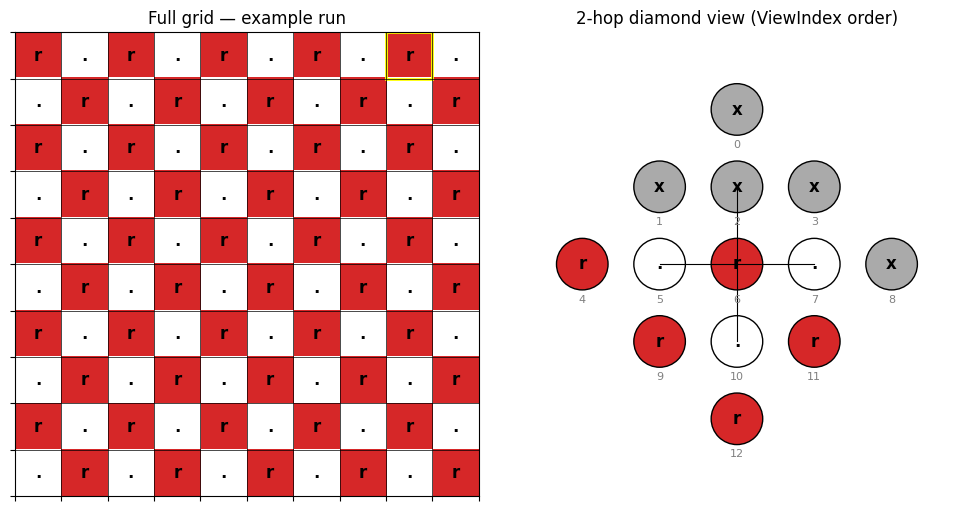

In [10]:
grid = parse_grid_string_to_2d(df.iloc[0, 1], meta_rows, meta_cols)
view = get_view(grid, 0, 8)
visualize_grid_and_view(grid, view, position=(0,8), title="example run")

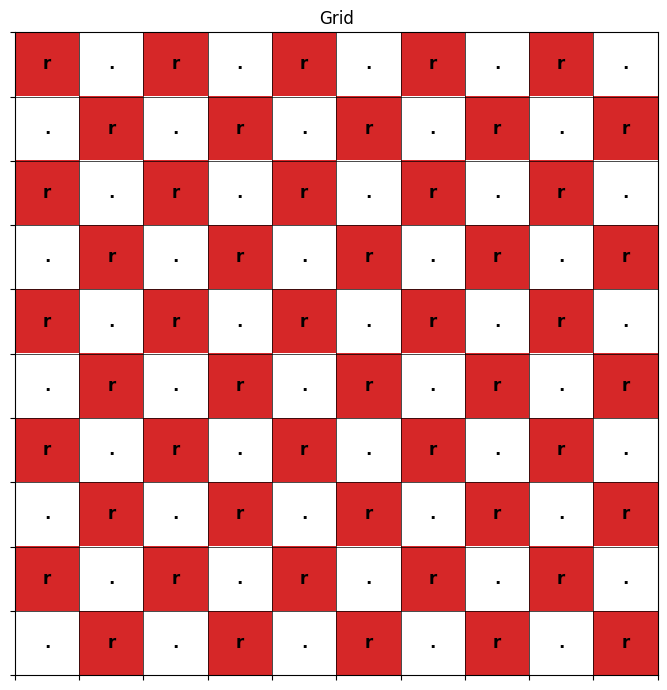

<Axes: title={'center': 'Grid'}>

In [11]:
visualize_grid(grid)

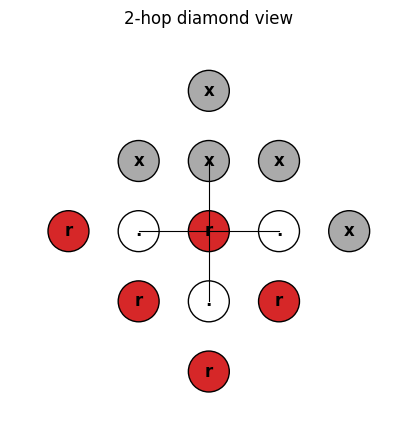

<Axes: title={'center': '2-hop diamond view'}>

In [12]:
visualize_view(view)

In [13]:

def compute_initial_green_frequency(df, rows, cols):
    """
    Computes a rows x cols matrix where each entry counts how many times
    that cell was 'g' in the initial_state.
    """
    freq = np.zeros((rows, cols), dtype=int)

    for grid_str in df["initial_grid"]:
        grid = parse_grid_string_to_2d(grid_str, rows, cols)
        for r in range(rows):
            for c in range(cols):
                if grid[r][c] == 'g':
                    freq[r, c] += 1

    return freq


def visualize_green_heatmap(freq_matrix, title="Initial Green Frequency"):
    """Plot the heatmap of green frequencies."""
    plt.figure(figsize=(7, 6))
    plt.imshow(freq_matrix, cmap="YlGnBu")
    plt.colorbar(label="Frequency of 'g' in initial state")
    plt.title(title)
    plt.xlabel("Column index")
    plt.ylabel("Row index")

    # Annotate each cell with its number
    rows, cols = freq_matrix.shape
    for r in range(rows):
        for c in range(cols):
            plt.text(c, r, str(freq_matrix[r, c]),
                     ha='center', va='center', color='black', fontsize=9)

    plt.tight_layout()
    plt.show()

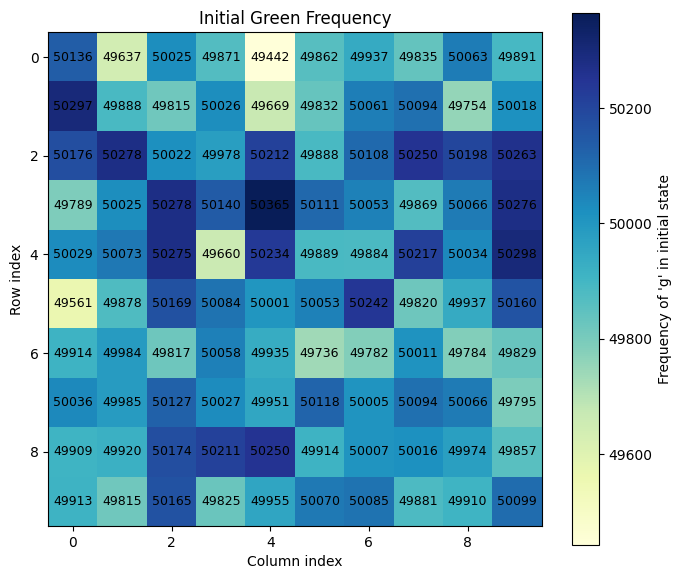

In [14]:
freq = compute_initial_green_frequency(df, meta_rows, meta_cols)
visualize_green_heatmap(freq)

In [15]:
print("random initialization posn frequency stats")
print(f"mean : {np.mean(freq)}, std: {np.std(freq)}")

random initialization posn frequency stats
mean : 50000.0, std: 175.19320763088962


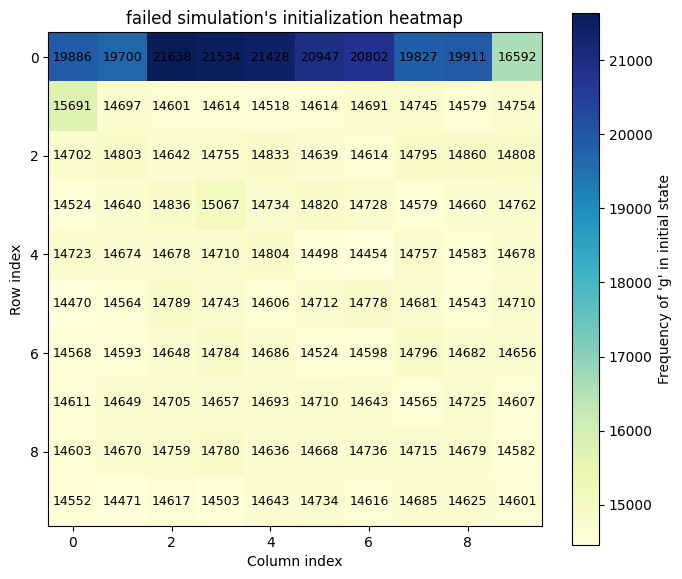

In [16]:
freq_failed = compute_initial_green_frequency(df.loc[df.label==0], meta_rows, meta_cols)
visualize_green_heatmap(freq_failed, title="failed simulation's initialization heatmap")

In [17]:
print("failed simulation's initialization posn frequency stats")
print(f"mean : {np.mean(freq_failed)}, std: {np.std(freq_failed)}")

failed simulation's initialization posn frequency stats
mean : 15237.0, std: 1727.4101308027575


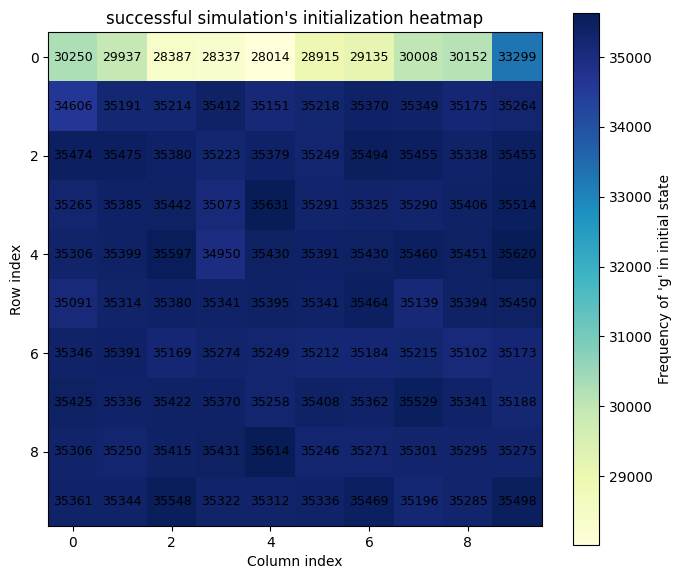

In [18]:
freq_successful = compute_initial_green_frequency(df.loc[df.label==1], meta_rows, meta_cols)
visualize_green_heatmap(freq_successful, title="successful simulation's initialization heatmap")

In [19]:
print("successful simulation's initialization posn frequency stats")
print(f"mean : {np.mean(freq_successful)}, std: {np.std(freq_successful)}")

successful simulation's initialization posn frequency stats
mean : 34763.0, std: 1772.386436418424
